# **TECH CHALLENGE 1** - E-commerce Olist  - Data Analytics FIAP - 2026



## Objetivo do notebook
Estruturação de análise executiva para investidores e acionistas, usando o dataset público da Olist, com foco em:

1. crescimento e receita;
2. logística e SLA;
3. comportamento de pagamento;
4. satisfação do cliente;
5. recomendações acionáveis.

## **1. Configuração do ambiente**

In [91]:
import os
import glob
import warnings
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Padrão visual dos gráficos
COR_BASE = "#0C29D0"
COR_DESTAQUE = "#E74C3C"
COR_NEUTRA = "#7F8C8D"

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

## **2. Carregamento dos dados**

In [92]:
DATA_PATH = Path("/content/drive/MyDrive/")

FILES = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "geolocation": "olist_geolocation_dataset.csv",
}

def read_csv_required(file_name: str, data_path: Path = DATA_PATH) -> pd.DataFrame:
    file_path = data_path / file_name
    if not file_path.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {file_path}. "
            "Verifique se os CSVs foram enviados ou ajuste DATA_PATH."
        )
    return pd.read_csv(file_path)

orders = read_csv_required(FILES["orders"])
items = read_csv_required(FILES["order_items"])
payments = read_csv_required(FILES["payments"])
customers = read_csv_required(FILES["customers"])
products = read_csv_required(FILES["products"])
sellers = read_csv_required(FILES["sellers"])
reviews = read_csv_required(FILES["reviews"])

try:
    category_translation = read_csv_required(FILES["category_translation"])
except FileNotFoundError:
    category_translation = pd.DataFrame(columns=["product_category_name", "product_category_name_english"])

try:
    geolocation = read_csv_required(FILES["geolocation"])
except FileNotFoundError:
    geolocation = pd.DataFrame()

print("Bases carregadas:")
for nome, base in {
    "orders": orders,
    "items": items,
    "payments": payments,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "reviews": reviews,
}.items():
    print(f"- {nome}: {base.shape[0]:,} linhas | {base.shape[1]} colunas")

Bases carregadas:
- orders: 99,441 linhas | 8 colunas
- items: 112,650 linhas | 7 colunas
- payments: 103,886 linhas | 5 colunas
- customers: 99,441 linhas | 5 colunas
- products: 32,951 linhas | 9 colunas
- sellers: 3,095 linhas | 4 colunas
- reviews: 99,224 linhas | 7 colunas


## **3. Preparação e governança dos dados**

In [93]:
# =============================
# Conversão de datas
# =============================
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")


# =============================
# Variáveis temporais
# =============================
orders["ano_mes"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["ano"] = orders["order_purchase_timestamp"].dt.year
orders["mes"] = orders["order_purchase_timestamp"].dt.month


# =============================
# Métricas logísticas
# =============================
orders["tempo_aprovacao_horas"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders["tempo_entrega_dias"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["dias_atraso"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders["pedido_atrasado"] = orders["dias_atraso"] > 0


# =============================
# Receita por item
# =============================
items["receita_item"] = items["price"] + items["freight_value"]


# =============================
# Receita por pedido (pagamentos)
# =============================
payment_order = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        receita_pagamento=("payment_value", "sum"),
        qtd_pagamentos=("payment_sequential", "count"),
        parcelas_medias=("payment_installments", "mean"),
    )
)


# =============================
# Categoria por pedido (FIX DO ERRO)
# =============================
categoria_pedido = (
    items
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

categoria_pedido["categoria"] = (
    categoria_pedido["product_category_name"]
    .fillna(categoria_pedido["product_category_name"])
    .fillna("Outros")
    .str.replace("_", " ")
    .str.title()
)

categoria_pedido = (
    categoria_pedido
    .groupby("order_id", as_index=False)
    .agg(categoria=("categoria", "first"))
)


# =============================
# Base principal (nível pedido)
# =============================
orders_base = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(payment_order, on="order_id", how="left")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
    .merge(categoria_pedido, on="order_id", how="left")
)

orders_base["categoria"] = orders_base["categoria"].fillna("Outros")


# =============================
# Base no nível item
# =============================
items_base = (
    items
    .merge(orders[["order_id", "customer_id", "order_purchase_timestamp", "ano_mes", "order_status"]], on="order_id", how="left")
    .merge(customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]], on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

items_base["categoria"] = (
    items_base["product_category_name"]
    .fillna(items_base["product_category_name"])
    .fillna("Outros")
    .str.replace("_", " ")
    .str.title()
)


# =============================
# Validação
# =============================
print("Base de pedidos:", orders_base.shape)
print("Base de itens:", items_base.shape)

Base de pedidos: (99992, 24)
Base de itens: (112650, 28)


### **3.1 Qualidade dos dados**

In [94]:
def qualidade_dados(df: pd.DataFrame, nome: str) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "base": nome,
        "coluna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "nulos": df.isna().sum().values,
        "perc_nulos": (df.isna().mean().values * 100).round(2),
        "valores_unicos": df.nunique(dropna=True).values,
    })
    return resumo.sort_values(["perc_nulos", "coluna"], ascending=[False, True])

qualidade = pd.concat([
    qualidade_dados(orders, "orders"),
    qualidade_dados(items, "items"),
    qualidade_dados(payments, "payments"),
    qualidade_dados(customers, "customers"),
    qualidade_dados(products, "products"),
    qualidade_dados(sellers, "sellers"),
    qualidade_dados(reviews, "reviews"),
], ignore_index=True)

qualidade.head(20)

,base,coluna,tipo,nulos,perc_nulos,valores_unicos
0,orders,dias_atraso,float64,2965,2.98,198
1,orders,order_delivered_customer_date,datetime64[ns],2965,2.98,95664
2,orders,tempo_entrega_dias,float64,2965,2.98,146
3,orders,order_delivered_carrier_date,datetime64[ns],1783,1.79,81018
4,orders,order_approved_at,datetime64[ns],160,0.16,90733
5,orders,tempo_aprovacao_horas,float64,160,0.16,33475
6,orders,ano,int32,0,0.00,3
7,orders,ano_mes,object,0,0.00,25
8,orders,customer_id,object,0,0.00,99441
9,orders,mes,int32,0,0.00,12


## 4. Indicadores executivos gerais

In [95]:
pedidos_total = orders_base["order_id"].nunique()
clientes_total = orders_base["customer_unique_id"].nunique()
sellers_total = items_base["seller_id"].nunique()
receita_total = orders_base["receita_pagamento"].sum()
ticket_medio = receita_total / pedidos_total
nota_media = orders_base["review_score"].mean()
tempo_entrega_medio = orders_base["tempo_entrega_dias"].mean()
perc_atraso = orders_base["pedido_atrasado"].mean() * 100

kpis = pd.DataFrame({
    "Indicador": [
        "Pedidos",
        "Clientes únicos",
        "Sellers",
        "Receita total",
        "Ticket médio",
        "Nota média",
        "Tempo médio de entrega",
        "% pedidos atrasados",
    ],
    "Valor": [
        f"{pedidos_total:,.0f}",
        f"{clientes_total:,.0f}",
        f"{sellers_total:,.0f}",
        f"R$ {receita_total:,.2f}",
        f"R$ {ticket_medio:,.2f}",
        f"{nota_media:.2f}",
        f"{tempo_entrega_medio:.1f} dias",
        f"{perc_atraso:.1f}%",
    ]
})

kpis

,Indicador,Valor
0,Pedidos,"99,441"
1,Clientes únicos,"96,096"
2,Sellers,"3,095"
3,Receita total,"R$ 16,081,420.74"
4,Ticket médio,R$ 161.72
5,Nota média,4.09
6,Tempo médio de entrega,12.1 dias
7,% pedidos atrasados,6.6%


# 5. **Trilha 1 - Crescimento e Receita**

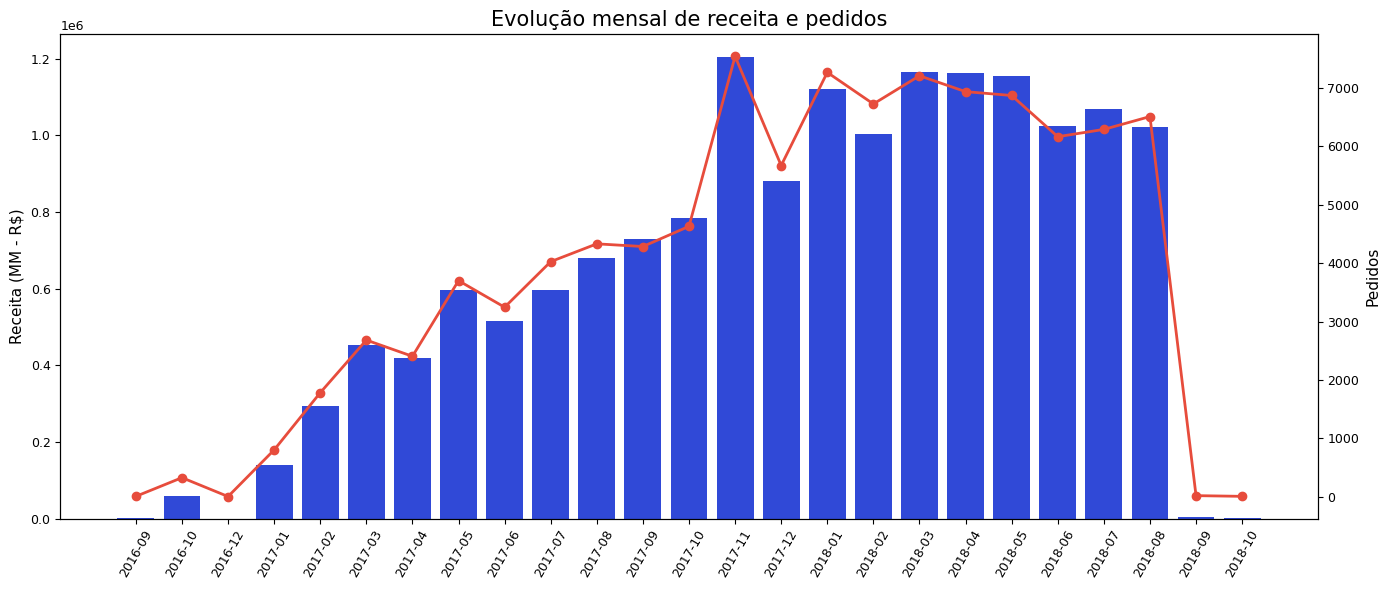

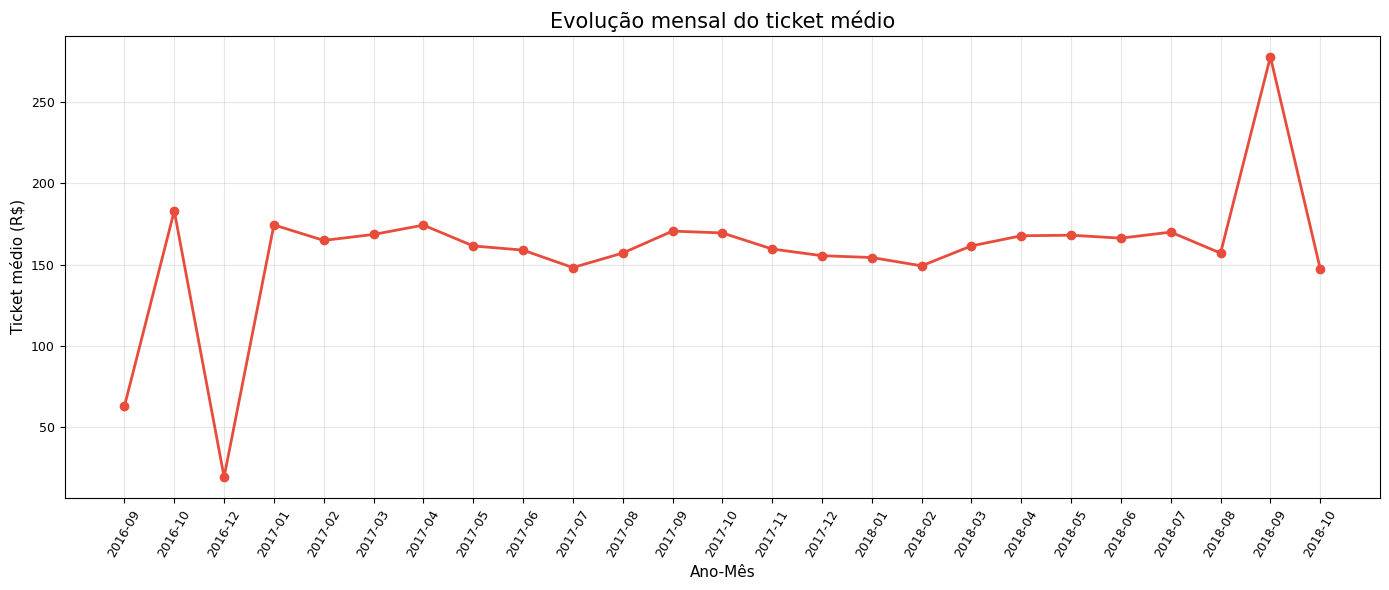

,ano_mes,pedidos,receita,clientes,ticket_medio
15,2018-01,7269,"1,121,631.30",7166,154.30
16,2018-02,6728,"1,003,785.44",6569,149.20
17,2018-03,7211,"1,164,189.28",7115,161.45
18,2018-04,6939,"1,163,314.66",6882,167.65
19,2018-05,6873,"1,154,674.66",6814,168.00
20,2018-06,6167,"1,024,877.86",6128,166.19
21,2018-07,6292,"1,069,017.37",6230,169.90
22,2018-08,6512,"1,022,530.02",6460,157.02
23,2018-09,16,"4,439.54",14,277.47
24,2018-10,4,589.67,4,147.42


In [96]:
#Receita e pedidos

receita_mes = (
    orders_base
    .groupby("ano_mes", as_index=False)
    .agg(
        pedidos=("order_id", "nunique"),
        receita=("receita_pagamento", "sum"),
        clientes=("customer_unique_id", "nunique"),
    )
)

receita_mes["ticket_medio"] = receita_mes["receita"] / receita_mes["pedidos"]

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(receita_mes["ano_mes"], receita_mes["receita"], color=COR_BASE, alpha=0.85, label="Receita")
ax1.set_ylabel("Receita (MM - R$)")
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(receita_mes["ano_mes"], receita_mes["pedidos"], color=COR_DESTAQUE, marker="o", linewidth=2, label="Pedidos")
ax2.set_ylabel("Pedidos")

plt.title("Evolução mensal de receita e pedidos")
fig.tight_layout()
plt.show()

#Ticket Médio

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    receita_mes["ano_mes"],
    receita_mes["ticket_medio"],
    color=COR_DESTAQUE,
    marker="o",
    linewidth=2
)

ax.set_title("Evolução mensal do ticket médio")
ax.set_ylabel("Ticket médio (R$)")
ax.set_xlabel("Ano-Mês")
ax.tick_params(axis="x", rotation=60)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Resumo dos indicadores de crescimento
receita_mes.tail(10)

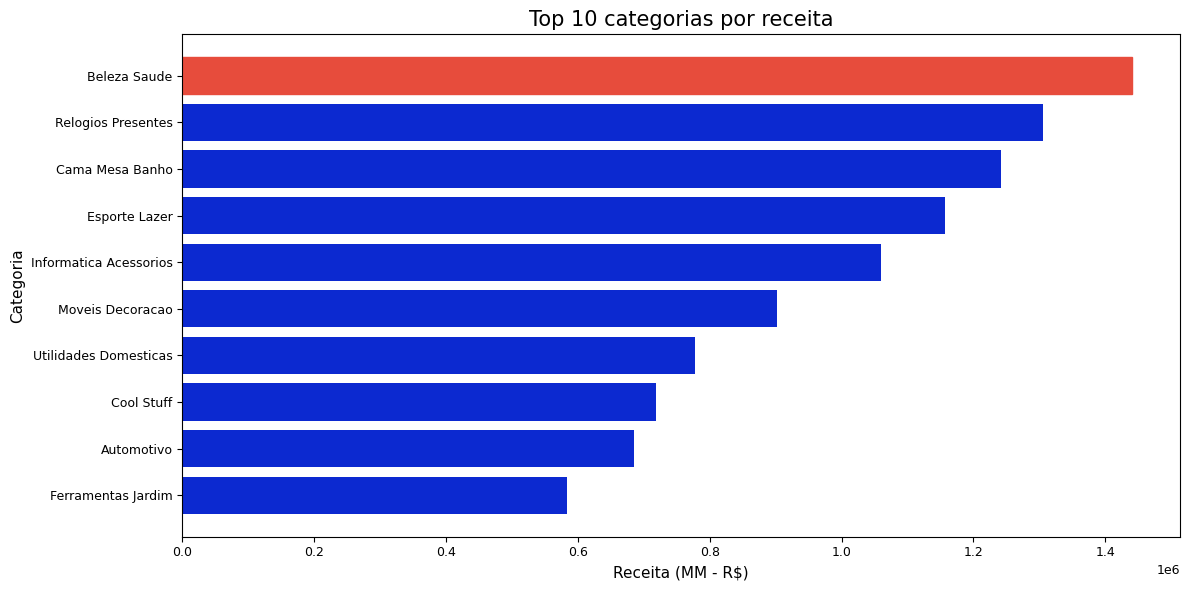

,categoria,receita,pedidos,ticket_item_medio
11,Beleza Saude,"1,441,248.07",8836,149.04
67,Relogios Presentes,"1,305,541.61",5624,217.92
13,Cama Mesa Banho,"1,241,681.72",9417,111.71
32,Esporte Lazer,"1,156,656.48",7720,133.86
44,Informatica Acessorios,"1,059,272.40",6689,135.34
54,Moveis Decoracao,"902,511.79",6449,108.29
73,Utilidades Domesticas,"778,397.77",5884,111.77
26,Cool Stuff,"719,329.95",3632,189.50
8,Automotivo,"685,384.32",3897,161.84
40,Ferramentas Jardim,"584,219.21",3518,134.40


In [97]:
top_categorias = (
    items_base
    .groupby("categoria", as_index=False)
    .agg(
        receita=("receita_item", "sum"),
        pedidos=("order_id", "nunique"),
        ticket_item_medio=("receita_item", "mean")
    )
    .sort_values("receita", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_categorias["categoria"][::-1], top_categorias["receita"][::-1], color=COR_BASE)
bars[-1].set_color(COR_DESTAQUE)
plt.title("Top 10 categorias por receita")
plt.xlabel("Receita (MM - R$)")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

top_categorias

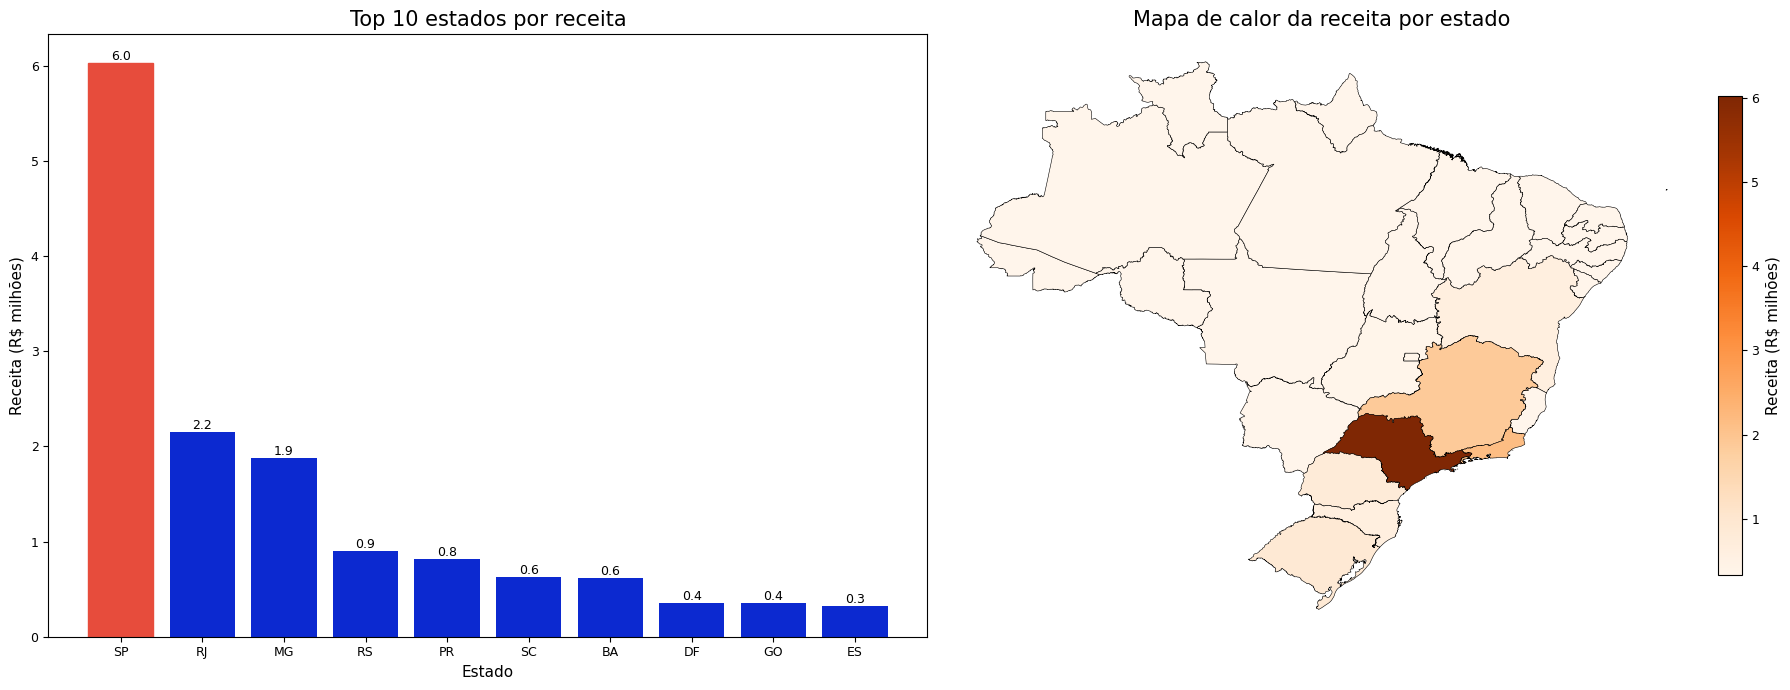

,customer_state,receita,pedidos
25,SP,"6,028,174.24",41746
18,RJ,"2,153,774.00",12852
10,MG,"1,879,983.51",11635
22,RS,"895,835.07",5466
17,PR,"814,542.64",5045
23,SC,"625,026.48",3637
4,BA,"618,916.38",3380
6,DF,"357,704.33",2140
8,GO,"353,545.47",2020
7,ES,"327,115.59",2033


In [98]:
receita_estado = (
    orders_base
    .groupby("customer_state", as_index=False)
    .agg(
        receita=("receita_pagamento", "sum"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("receita", ascending=False)
    .head(10)
)

top_estados = receita_estado.head(10)

#JSON dos estados brasileiros
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson_brasil = requests.get(url_geojson).json()

mapa_estado = receita_estado.copy()
mapa_estado["receita_mi"] = mapa_estado["receita"] / 1_000_000
receita_por_uf = dict(zip(mapa_estado["customer_state"], mapa_estado["receita_mi"]))

for feature in geojson_brasil["features"]:
    uf = feature["properties"]["sigla"]
    feature["properties"]["receita_mi"] = receita_por_uf.get(uf, 0)

fig, (ax_bar, ax_map) = plt.subplots(
    1, 2,
    figsize=(18, 7),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# Barras
bars = ax_bar.bar(top_estados["customer_state"], top_estados["receita"] / 1_000_000, color=COR_BASE)
bars[0].set_color(COR_DESTAQUE)

ax_bar.set_title("Top 10 estados por receita")
ax_bar.set_xlabel("Estado")
ax_bar.set_ylabel("Receita (R$ milhões)")

for i, v in enumerate(top_estados["receita"] / 1_000_000):
    ax_bar.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

# Mapa
valores = list(receita_por_uf.values())
vmin, vmax = min(valores), max(valores)

cmap = plt.cm.Oranges
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for feature in geojson_brasil["features"]:
    geom = feature["geometry"]
    receita = feature["properties"]["receita_mi"]
    cor = cmap(norm(receita))

    polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]

    for polygon in polygons:
        for coords in polygon:
            xs = [p[0] for p in coords]
            ys = [p[1] for p in coords]
            ax_map.fill(xs, ys, color=cor, edgecolor="black", linewidth=0.4)

ax_map.set_title("Mapa de calor da receita por estado")
ax_map.axis("off")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_map, fraction=0.03, pad=0.02)
cbar.set_label("Receita (R$ milhões)")

plt.tight_layout()
plt.show()

top_estados

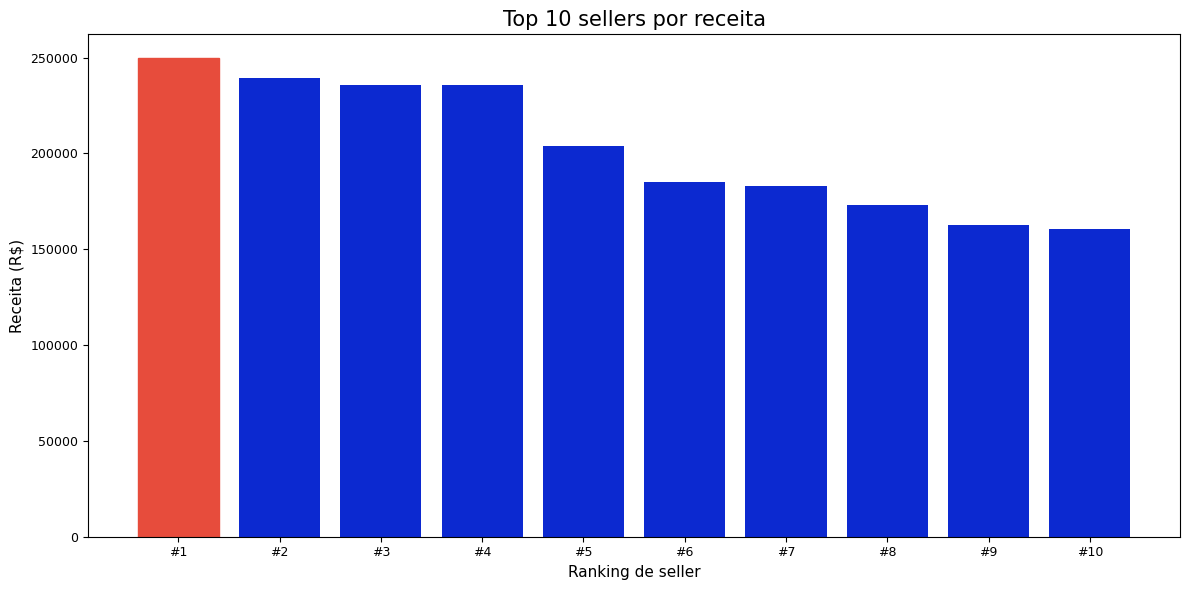

,ranking,seller_id,receita,pedidos,categorias
857,1,4869f7a5dfa277a7dca6462dcf3b52b2,"249,640.70",1132,10
1535,2,7c67e1448b00f6e969d365cea6b010ab,"239,536.44",982,6
1013,3,53243585a1d6dc2643021fd1853d8905,"235,856.68",358,2
881,4,4a3ca9315b744ce9f8e9374361493884,"235,539.96",1806,7
3024,5,fa1c13f2614d7b5c4749cbc52fecda94,"204,084.73",585,5
2643,6,da8622b14eb17ae2831f4ac5b9dab84a,"185,192.32",1314,4
1560,7,7e93a43ef30c4f03f38b393420bc753a,"182,754.05",336,8
192,8,1025f0e2d44d7041d6cf58b6550e0bfa,"172,860.69",915,4
1505,9,7a67c85e85bb2ce8582c35f2203ad736,"162,648.38",1160,2
1824,10,955fee9216a65b617aa5c0531780ce60,"160,602.68",1287,23


In [99]:
receita_seller = (
    items_base
    .groupby("seller_id", as_index=False)
    .agg(
        receita=("receita_item", "sum"),
        pedidos=("order_id", "nunique"),
        categorias=("categoria", "nunique"),
    )
    .sort_values("receita", ascending=False)
)

receita_seller["ranking"] = receita_seller["receita"].rank(method="first", ascending=False).astype(int)

# Reordena colunas
receita_seller = receita_seller[
    ["ranking", "seller_id", "receita", "pedidos", "categorias"]
]

top_sellers = receita_seller.head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_sellers)), top_sellers["receita"], color=COR_BASE)
bars[0].set_color(COR_DESTAQUE)
plt.title("Top 10 sellers por receita")
plt.xlabel("Ranking de seller")
plt.ylabel("Receita (R$)")
plt.xticks(range(len(top_sellers)), [f"#{i+1}" for i in range(len(top_sellers))])
plt.tight_layout()
plt.show()

top_sellers

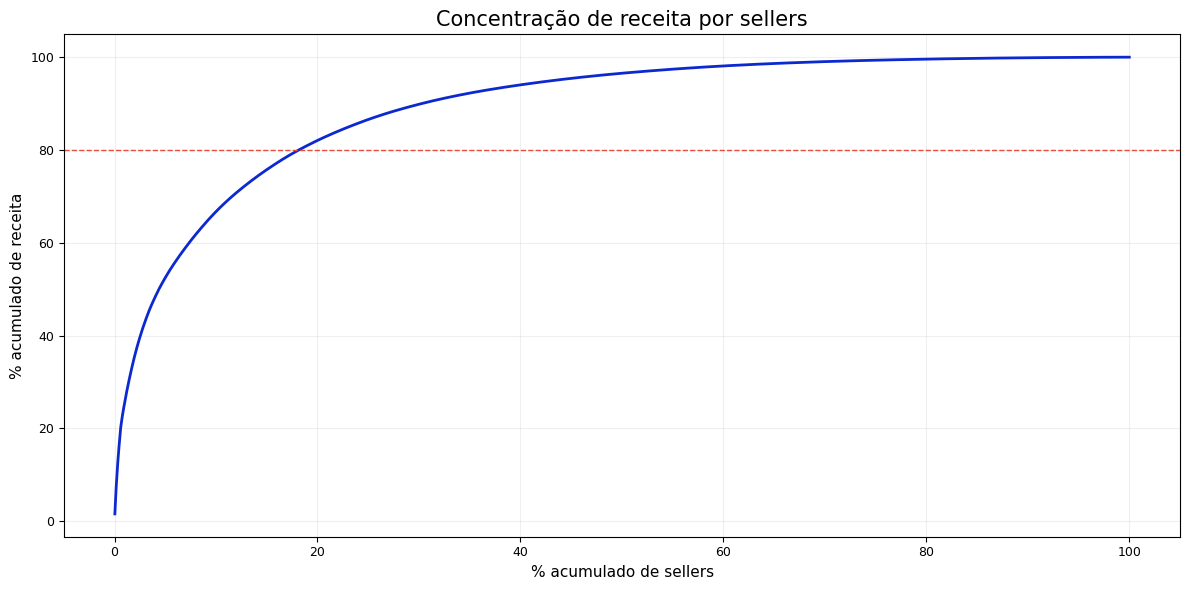

Aproximadamente 18.2% dos sellers concentram 80% da receita.


In [100]:
# Curva de concentração/Pareto de sellers
pareto = receita_seller.copy()
pareto["receita_acumulada"] = pareto["receita"].cumsum()
pareto["perc_receita_acumulada"] = pareto["receita_acumulada"] / pareto["receita"].sum() * 100
pareto["perc_sellers"] = (np.arange(1, len(pareto) + 1) / len(pareto)) * 100

plt.figure(figsize=(12, 6))
plt.plot(pareto["perc_sellers"], pareto["perc_receita_acumulada"], color=COR_BASE, linewidth=2)
plt.axhline(80, color=COR_DESTAQUE, linestyle="--", linewidth=1)
plt.title("Concentração de receita por sellers")
plt.xlabel("% acumulado de sellers")
plt.ylabel("% acumulado de receita")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

qtd_sellers_80 = pareto.loc[pareto["perc_receita_acumulada"] >= 80, "perc_sellers"].iloc[0]
print(f"Aproximadamente {qtd_sellers_80:.1f}% dos sellers concentram 80% da receita.")

# 6. **Trilha 2 - Logística e SLA**

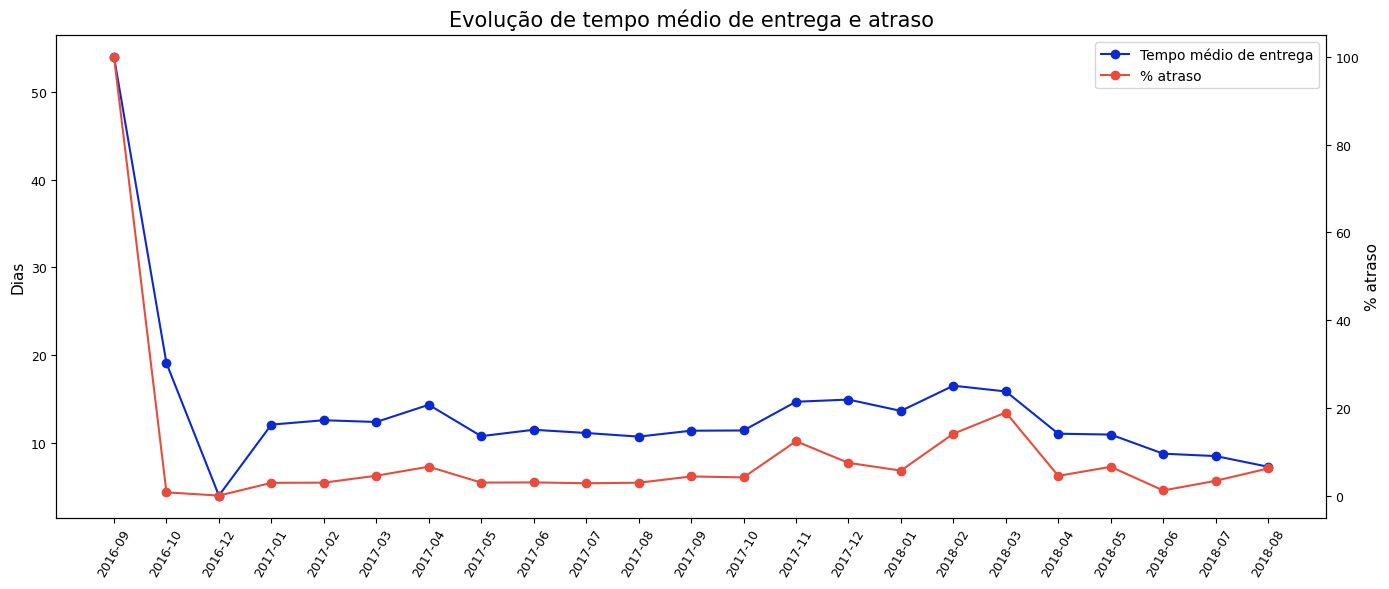

,ano_mes,tempo_entrega_medio,perc_atraso,nota_media,pedidos
13,2017-11,14.69,12.38,3.99,7288
14,2017-12,14.94,7.46,4.09,5513
15,2018-01,13.65,5.70,4.11,7069
16,2018-02,16.52,14.10,3.88,6556
17,2018-03,15.87,18.93,3.81,7003
18,2018-04,11.05,4.49,4.21,6798
19,2018-05,10.95,6.56,4.24,6749
20,2018-06,8.77,1.16,4.31,6096
21,2018-07,8.50,3.37,4.32,6156
22,2018-08,7.29,6.19,4.31,6351


In [101]:
logistica_mes = (
    orders_base
    .dropna(subset=["tempo_entrega_dias"])
    .groupby("ano_mes", as_index=False)
    .agg(
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        perc_atraso=("pedido_atrasado", "mean"),
        nota_media=("review_score", "mean"),
        pedidos=("order_id", "nunique"),
    )
)

logistica_mes["perc_atraso"] *= 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(logistica_mes["ano_mes"], logistica_mes["tempo_entrega_medio"], color=COR_BASE, marker="o", label="Tempo médio de entrega")
ax1.set_ylabel("Dias")
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(logistica_mes["ano_mes"], logistica_mes["perc_atraso"], color=COR_DESTAQUE, marker="o", label="% atraso")
ax2.set_ylabel("% atraso")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

plt.title("Evolução de tempo médio de entrega e atraso")
fig.tight_layout()
plt.show()

logistica_mes.tail(10)

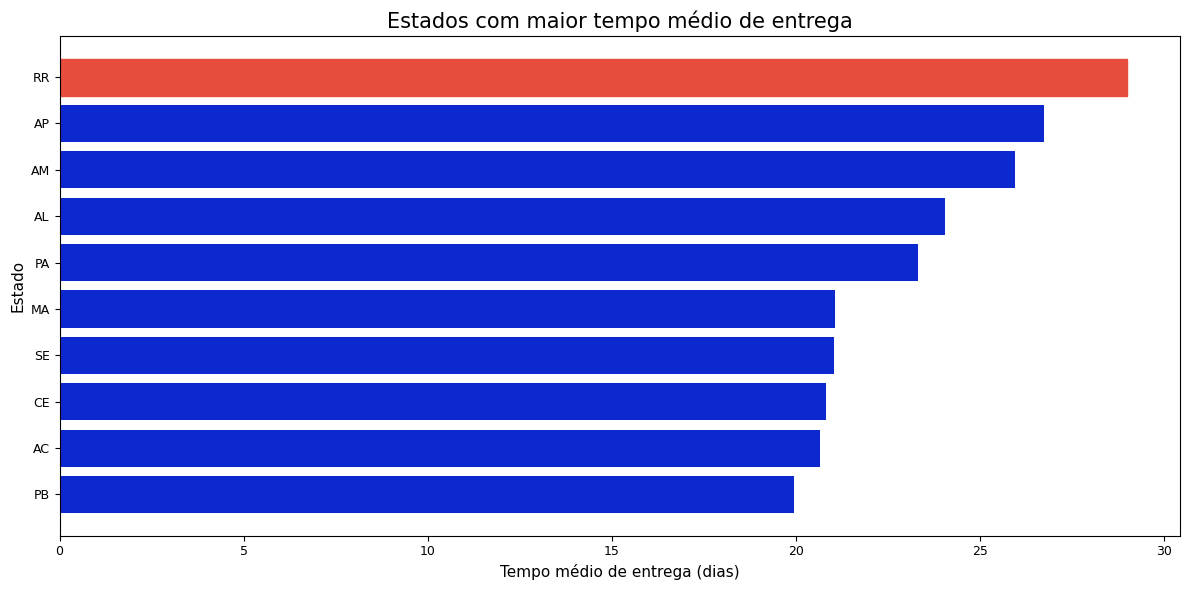

,customer_state,tempo_entrega_medio,perc_atraso,nota_media,pedidos
21,RR,28.98,12.20,3.90,41
3,AP,26.73,2.99,4.24,67
2,AM,25.95,2.74,4.22,145
1,AL,24.03,21.45,3.84,397
13,PA,23.32,11.13,3.91,946
9,MA,21.07,17.34,3.84,717
24,SE,21.03,15.22,3.91,335
5,CE,20.82,13.81,3.94,1279
0,AC,20.64,3.75,4.09,80
14,PB,19.93,10.42,4.08,517


In [102]:
entrega_estado = (
    orders_base
    .dropna(subset=["tempo_entrega_dias"])
    .groupby("customer_state", as_index=False)
    .agg(
        tempo_entrega_medio=("tempo_entrega_dias", "mean"),
        perc_atraso=("pedido_atrasado", "mean"),
        nota_media=("review_score", "mean"),
        pedidos=("order_id", "nunique"),
    )
)

entrega_estado["perc_atraso"] *= 100
entrega_estado = entrega_estado.sort_values("tempo_entrega_medio", ascending=False)

top_entrega_estado = entrega_estado.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_entrega_estado["customer_state"][::-1], top_entrega_estado["tempo_entrega_medio"][::-1], color=COR_BASE)
bars[-1].set_color(COR_DESTAQUE)
plt.title("Estados com maior tempo médio de entrega")
plt.xlabel("Tempo médio de entrega (dias)")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

top_entrega_estado

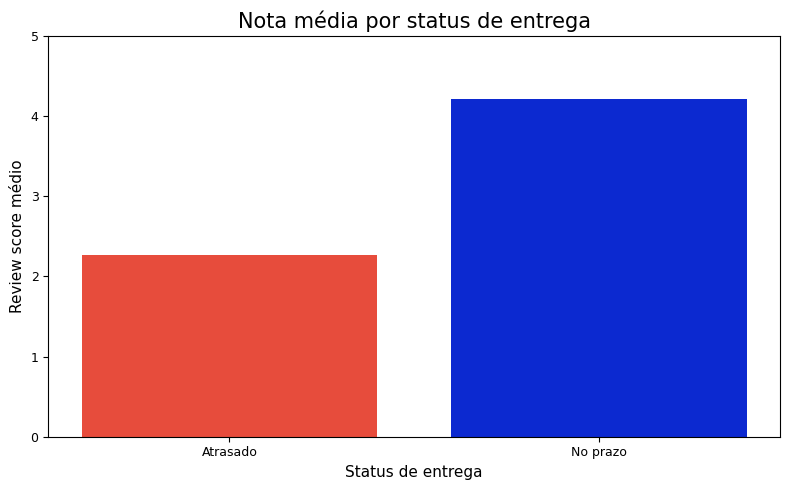

,status_entrega,nota_media,pedidos,tempo_entrega_medio
0,Atrasado,2.27,6382,33.38
1,No prazo,4.21,92291,10.54


In [103]:
satisfacao_atraso = (
    orders_base
    .dropna(subset=["review_score"])
    .assign(status_entrega=lambda x: np.where(x["pedido_atrasado"], "Atrasado", "No prazo"))
    .groupby("status_entrega", as_index=False)
    .agg(
        nota_media=("review_score", "mean"),
        pedidos=("order_id", "nunique"),
        tempo_entrega_medio=("tempo_entrega_dias", "mean")
    )
)

plt.figure(figsize=(8, 5))
bars = plt.bar(satisfacao_atraso["status_entrega"], satisfacao_atraso["nota_media"], color=[COR_DESTAQUE, COR_BASE])
plt.title("Nota média por status de entrega")
plt.xlabel("Status de entrega")
plt.ylabel("Review score médio")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

satisfacao_atraso

# 7. **Trilha 3 - Comportamento e Pagamentos**

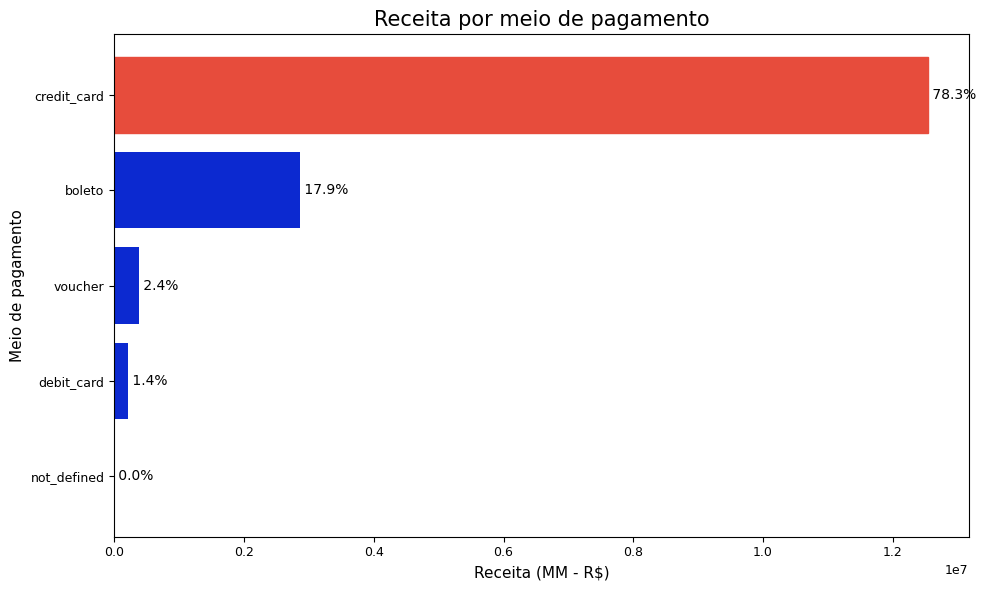

In [104]:
pagamentos_tipo = (
    payments
    .groupby("payment_type", as_index=False)
    .agg(
        receita=("payment_value", "sum"),
        qtd_pagamentos=("order_id", "count"),
        ticket_medio=("payment_value", "mean"),
        parcelas_medias=("payment_installments", "mean"),
    )
    .sort_values("receita", ascending=False)
)

pagamentos_tipo["percentual"] = (
    pagamentos_tipo["receita"] / pagamentos_tipo["receita"].sum() * 100
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    pagamentos_tipo["payment_type"][::-1],
    pagamentos_tipo["receita"][::-1],
    color=COR_BASE
)

bars[-1].set_color(COR_DESTAQUE)

plt.title("Receita por meio de pagamento")
plt.xlabel("Receita (MM - R$)")
plt.ylabel("Meio de pagamento")

# Rótulo com percentual
for i, (v, p) in enumerate(zip(
    pagamentos_tipo["receita"][::-1],
    pagamentos_tipo["percentual"][::-1]
)):
    plt.text(
        v,
        i,
        f" {p:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

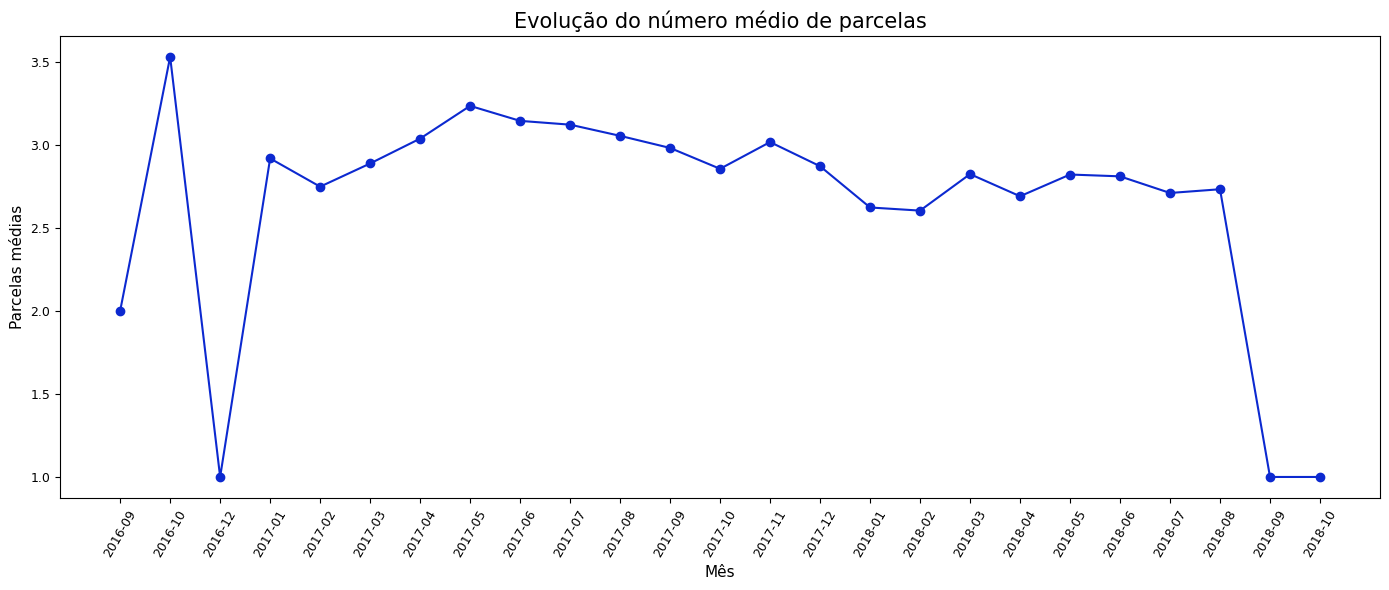

,ano_mes,parcelas_medias,ticket_medio
15,2018-01,2.62,147.43
16,2018-02,2.60,142.76
17,2018-03,2.82,154.37
18,2018-04,2.69,161.02
19,2018-05,2.82,161.74
20,2018-06,2.81,159.51
21,2018-07,2.71,163.91
22,2018-08,2.73,152.65
23,2018-09,1.00,277.47
24,2018-10,1.00,147.42


In [105]:
parcelas_mes = (
    orders[["order_id", "ano_mes"]]
    .merge(payments[["order_id", "payment_installments", "payment_value"]], on="order_id", how="left")
    .groupby("ano_mes", as_index=False)
    .agg(
        parcelas_medias=("payment_installments", "mean"),
        ticket_medio=("payment_value", "mean")
    )
)

plt.figure(figsize=(14, 6))
plt.plot(parcelas_mes["ano_mes"], parcelas_mes["parcelas_medias"], color=COR_BASE, marker="o")
plt.title("Evolução do número médio de parcelas")
plt.xlabel("Mês")
plt.ylabel("Parcelas médias")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

parcelas_mes.tail(10)

In [106]:

#Avaliação de quantidade de pedidos por quantidade de parcelas
parcelamento = (
    payments
    .groupby("payment_installments", as_index=False)
    .agg(
        pedidos=("order_id", "nunique")
    )
    .sort_values("payment_installments")
)

parcelamento

,payment_installments,pedidos
0,0,2
1,1,49060
2,2,12389
3,3,10443
4,4,7088
5,5,5234
6,6,3916
7,7,1623
8,8,4253
9,9,644


In [107]:
def formatar_moeda(valor):
    return f"R$ {valor:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Base RFM no nível cliente
data_referencia = orders_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    orders_base
    .dropna(subset=["customer_unique_id", "order_purchase_timestamp"])
    .groupby("customer_unique_id", as_index=False)
    .agg(
        ultima_compra=("order_purchase_timestamp", "max"),
        frequencia=("order_id", "nunique"),
        monetizacao=("receita_pagamento", "sum"),
        ticket_medio_cliente=("receita_pagamento", "mean"),
    )
)

rfm["recencia_dias"] = (data_referencia - rfm["ultima_compra"]).dt.days
rfm["cliente_recorrente"] = rfm["frequencia"] > 1

taxa_recompra = rfm["cliente_recorrente"].mean() * 100
clientes_recorrentes = rfm["cliente_recorrente"].sum()

resumo_rfm = pd.DataFrame({
    "Indicador": [
        "Clientes analisados",
        "Clientes recorrentes",
        "Taxa de recompra",
        "Frequência média",
        "Monetização média por cliente",
        "Recência média"
    ],
    "Valor": [
        f"{rfm['customer_unique_id'].nunique():,.0f}",
        f"{clientes_recorrentes:,.0f}",
        f"{taxa_recompra:.2f}%",
        f"{rfm['frequencia'].mean():.2f}",
        formatar_moeda(rfm["monetizacao"].mean()),
        f"{rfm['recencia_dias'].mean():.1f} dias",
    ]
})

resumo_rfm

,Indicador,Valor
0,Clientes analisados,"96,096"
1,Clientes recorrentes,"2,997"
2,Taxa de recompra,3.12%
3,Frequência média,1.03
4,Monetização média por cliente,R$ 167
5,Recência média,288.7 dias


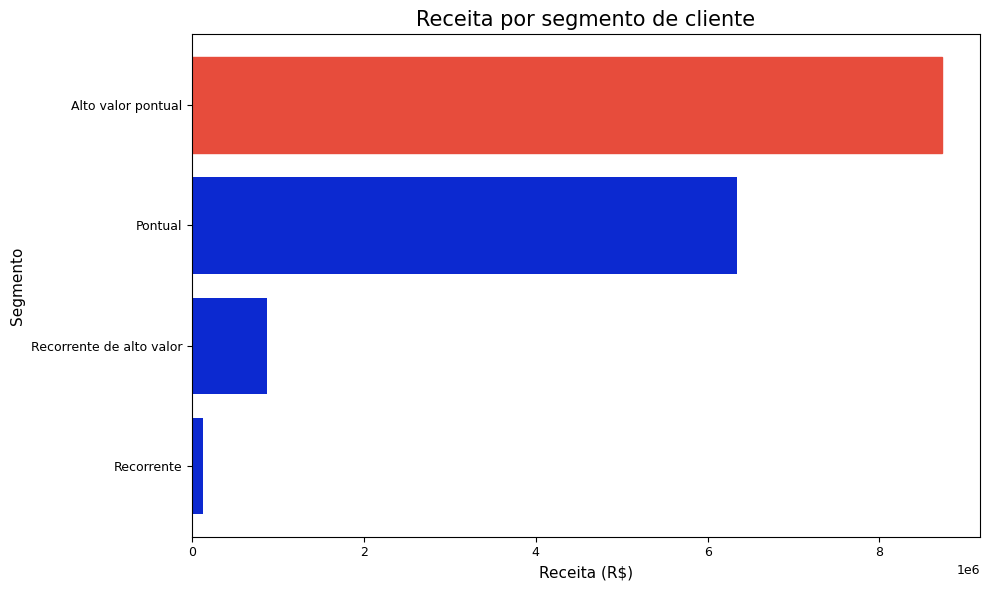

,segmento_cliente,clientes,receita,frequencia_media,recencia_media,participacao_receita_%
0,Alto valor pontual,22049,"8,732,554.68",1.00,289.09,54.30
1,Pontual,71050,"6,342,013.27",1.00,289.45,39.44
3,Recorrente de alto valor,1975,"878,364.60",2.16,266.10,5.46
2,Recorrente,1022,"128,488.19",2.04,275.21,0.80


In [108]:
# Segmentação simples de clientes por valor e frequência
rfm["segmento_cliente"] = np.select(
    [
        (rfm["frequencia"] > 1) & (rfm["monetizacao"] >= rfm["monetizacao"].quantile(0.75)),
        (rfm["frequencia"] > 1),
        (rfm["monetizacao"] >= rfm["monetizacao"].quantile(0.75)),
    ],
    [
        "Recorrente de alto valor",
        "Recorrente",
        "Alto valor pontual",
    ],
    default="Pontual"
)

segmentos_rfm = (
    rfm
    .groupby("segmento_cliente", as_index=False)
    .agg(
        clientes=("customer_unique_id", "nunique"),
        receita=("monetizacao", "sum"),
        frequencia_media=("frequencia", "mean"),
        recencia_media=("recencia_dias", "mean")
    )
    .sort_values("receita", ascending=False)
)

segmentos_rfm["participacao_receita_%"] = segmentos_rfm["receita"] / segmentos_rfm["receita"].sum() * 100

plt.figure(figsize=(10, 6))
bars = plt.barh(segmentos_rfm["segmento_cliente"][::-1], segmentos_rfm["receita"][::-1], color=COR_BASE)
bars[-1].set_color(COR_DESTAQUE)
plt.title("Receita por segmento de cliente")
plt.xlabel("Receita (R$)")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()

segmentos_rfm

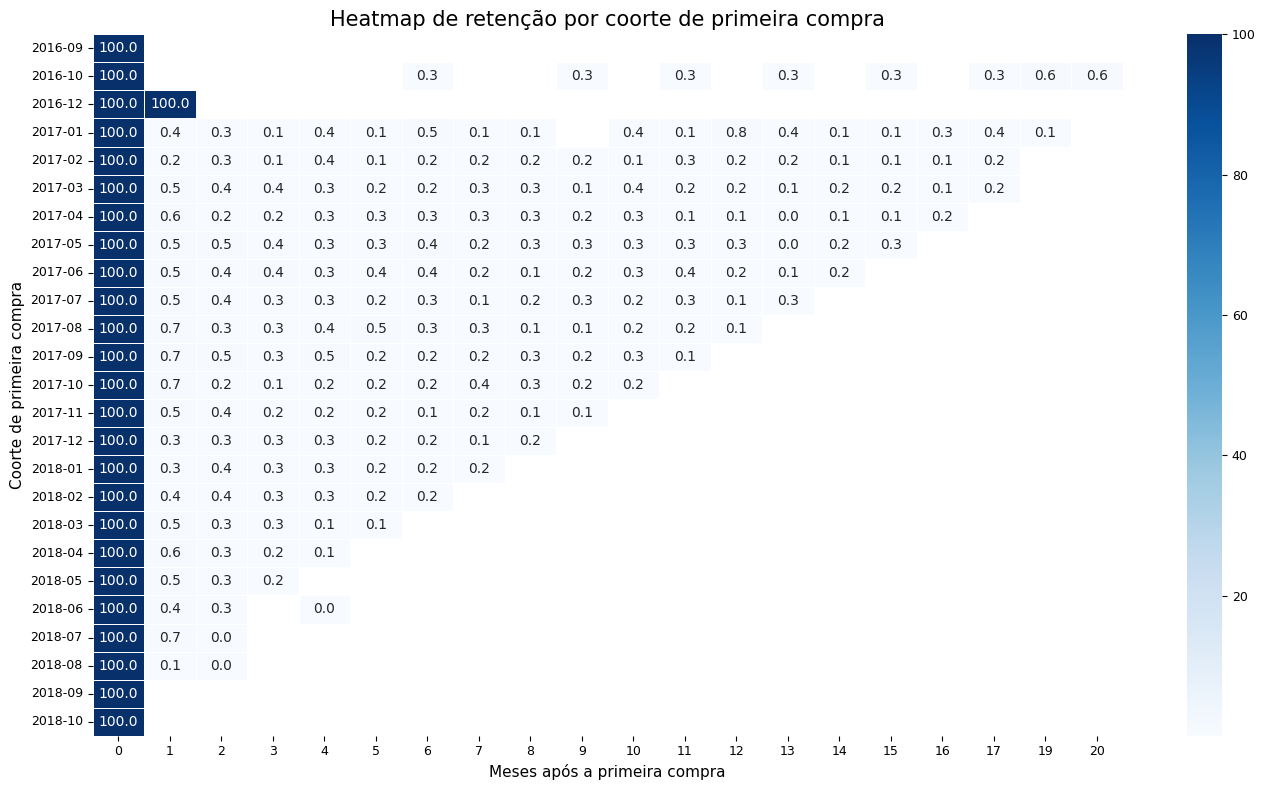

In [109]:
# Matriz de coorte: retenção/recompra por meses desde a primeira compra
compras_cliente = (
    orders_base
    .dropna(subset=["customer_unique_id", "order_purchase_timestamp"])
    [["customer_unique_id", "order_id", "order_purchase_timestamp"]]
    .drop_duplicates()
)

compras_cliente["mes_compra"] = compras_cliente["order_purchase_timestamp"].dt.to_period("M")

primeira_compra = (
    compras_cliente
    .groupby("customer_unique_id", as_index=False)
    .agg(coorte=("mes_compra", "min"))
)

compras_coorte = compras_cliente.merge(primeira_compra, on="customer_unique_id", how="left")

compras_coorte["idade_coorte"] = (
    (compras_coorte["mes_compra"].dt.year - compras_coorte["coorte"].dt.year) * 12
    + (compras_coorte["mes_compra"].dt.month - compras_coorte["coorte"].dt.month)
)

coorte_matriz = (
    compras_coorte
    .groupby(["coorte", "idade_coorte"])
    .agg(clientes=("customer_unique_id", "nunique"))
    .reset_index()
)

coorte_pivot = coorte_matriz.pivot(
    index="coorte",
    columns="idade_coorte",
    values="clientes"
)

coorte_retencao = coorte_pivot.divide(coorte_pivot[0], axis=0) * 100

plt.figure(figsize=(14, 8))

sns.heatmap(
    coorte_retencao,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Heatmap de retenção por coorte de primeira compra")
plt.xlabel("Meses após a primeira compra")
plt.ylabel("Coorte de primeira compra")
plt.tight_layout()
plt.show()


# 8. **Trilha 4 - Satisfação do cliente**

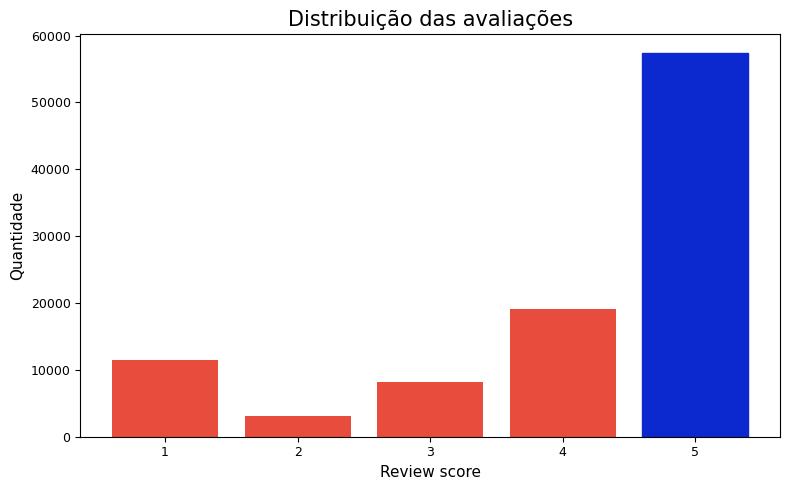

,review_score,quantidade
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [110]:
notas = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)
notas.columns = ["review_score", "quantidade"]

plt.figure(figsize=(8, 5))
bars = plt.bar(notas["review_score"], notas["quantidade"], color=COR_DESTAQUE)
bars[notas["quantidade"].idxmax()].set_color(COR_BASE)
plt.title("Distribuição das avaliações")
plt.xlabel("Review score")
plt.ylabel("Quantidade")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

notas

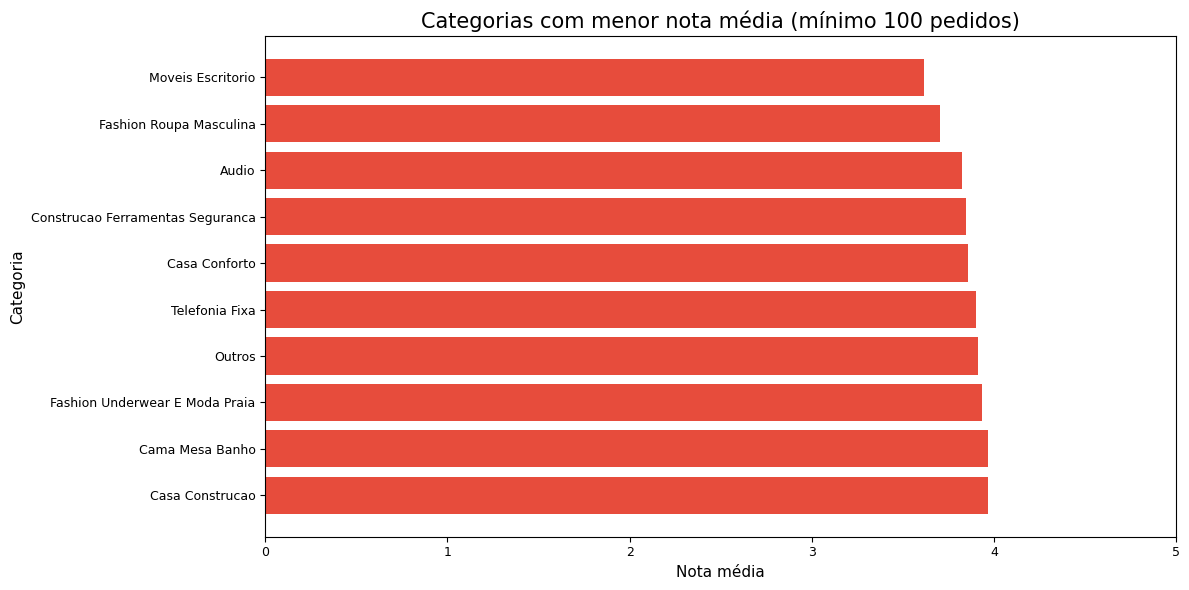

,categoria,nota_media,pedidos
55,Moveis Escritorio,3.62,1263
38,Fashion Roupa Masculina,3.70,111
7,Audio,3.83,347
25,Construcao Ferramentas Seguranca,3.85,166
14,Casa Conforto,3.86,395
72,Telefonia Fixa,3.90,214
59,Outros,3.91,1439
39,Fashion Underwear E Moda Praia,3.93,120
13,Cama Mesa Banho,3.97,9313
16,Casa Construcao,3.97,487


In [111]:
satisfacao_categoria = (
    items_base[["order_id", "categoria"]]
    .drop_duplicates()
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
    .dropna(subset=["review_score"])
    .groupby("categoria", as_index=False)
    .agg(
        nota_media=("review_score", "mean"),
        pedidos=("order_id", "nunique")
    )
)

# Mantém categorias com volume mínimo
min_pedidos = 100
piores_categorias = (
    satisfacao_categoria
    .query("pedidos >= @min_pedidos")
    .sort_values("nota_media", ascending=True)
    .head(10)
)

plt.figure(figsize=(12, 6))
bars = plt.barh(piores_categorias["categoria"][::-1], piores_categorias["nota_media"][::-1], color=COR_DESTAQUE)
plt.title(f"Categorias com menor nota média (mínimo {min_pedidos} pedidos)")
plt.xlabel("Nota média")
plt.ylabel("Categoria")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

piores_categorias

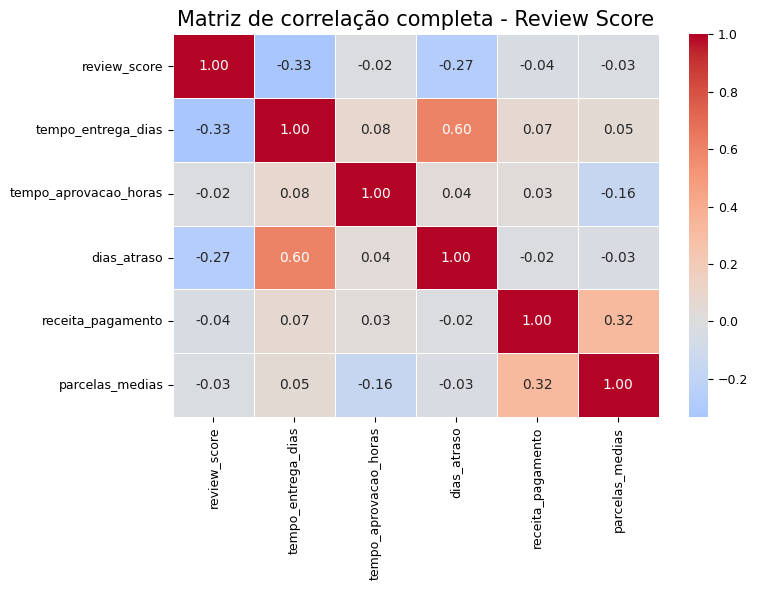

In [112]:
fatores_satisfacao = orders_base[
    [
        "review_score",
        "tempo_entrega_dias",
        "tempo_aprovacao_horas",
        "dias_atraso",
        "receita_pagamento",
        "parcelas_medias",
    ]
].dropna()

correlacoes = (
    fatores_satisfacao
    .corr(numeric_only=True)["review_score"]
    .drop("review_score")
    .sort_values()
    .reset_index()
)


correlacoes.columns = ["variavel", "correlacao_com_review_score"]

corr_matrix = fatores_satisfacao.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlação completa - Review Score")
plt.tight_layout()
plt.show()

# 9. Previsão simples de receita

A previsão abaixo usa tendência linear sobre os últimos meses disponíveis.  
Ela deve ser interpretada como estimativa exploratória, não como modelo final de demanda.

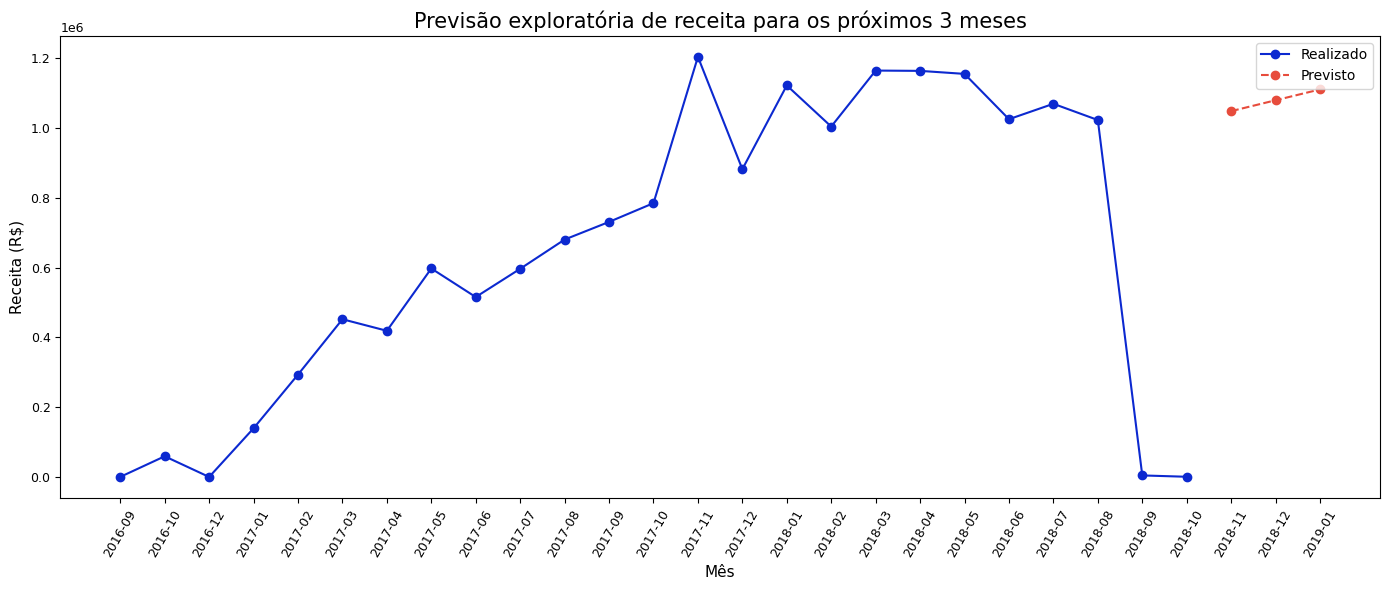

,ano_mes,receita_prevista
0,2018-11,"1,047,971.01"
1,2018-12,"1,079,102.87"
2,2019-01,"1,110,234.73"


In [113]:
serie = receita_mes[["ano_mes", "receita"]].copy().dropna()
serie = serie.sort_values("ano_mes").reset_index(drop=True)

# Remove meses muito incompletos nas bordas, se necessário
serie_modelo = serie.copy()

x = np.arange(len(serie_modelo))
y = serie_modelo["receita"].values

coef = np.polyfit(x, y, deg=1)
modelo_linear = np.poly1d(coef)

horizonte = 3
x_futuro = np.arange(len(serie_modelo), len(serie_modelo) + horizonte)
previsao = modelo_linear(x_futuro)

ult_mes = pd.Period(serie_modelo["ano_mes"].iloc[-1], freq="M")
meses_futuros = [(ult_mes + i).strftime("%Y-%m") for i in range(1, horizonte + 1)]

forecast = pd.DataFrame({
    "ano_mes": meses_futuros,
    "receita_prevista": previsao
})

plt.figure(figsize=(14, 6))
plt.plot(serie_modelo["ano_mes"], serie_modelo["receita"], color=COR_BASE, marker="o", label="Realizado")
plt.plot(forecast["ano_mes"], forecast["receita_prevista"], color=COR_DESTAQUE, marker="o", linestyle="--", label="Previsto")
plt.title("Previsão exploratória de receita para os próximos 3 meses")
plt.xlabel("Mês")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()
plt.show()

forecast

# 10. Oportunidades e recomendações executivas

Esta seção transforma os achados em ações de negócio para investidores e acionistas.

In [114]:
# Regras simples para gerar recomendações baseadas nos dados calculados

maior_estado_receita = receita_estado.iloc[0]["customer_state"]
maior_categoria = top_categorias.iloc[0]["categoria"]
categoria_pior_nota = piores_categorias.iloc[0]["categoria"] if len(piores_categorias) else "não identificado"
estado_maior_entrega = top_entrega_estado.iloc[0]["customer_state"]
pagamento_lider = pagamentos_tipo.iloc[0]["payment_type"]

recomendacoes = pd.DataFrame({
    "Tema": [
        "Crescimento",
        "Concentração de sellers",
        "Logística",
        "Satisfação",
        "Pagamentos",
    ],
    "Achado": [
        f"O estado {maior_estado_receita} lidera a receita e pode ser priorizado em campanhas regionais.",
        f"A receita é concentrada: cerca de {qtd_sellers_80:.1f}% dos sellers acumulam 80% da receita.",
        f"O estado {estado_maior_entrega} apresenta um dos maiores tempos médios de entrega.",
        f"A categoria {categoria_pior_nota} aparece entre as menores notas médias com volume relevante.",
        f"O meio de pagamento {pagamento_lider} concentra o maior volume financeiro.",
    ],
    "Recomendação": [
        "Direcionar aquisição e sortimento para regiões com alta receita e base ativa.",
        "Criar programa de desenvolvimento e retenção de sellers estratégicos.",
        "Revisar rotas, transportadoras e SLA nas regiões críticas.",
        "Investigar causas de reclamação por categoria e atuar em qualidade, prazo e comunicação.",
        "Otimizar campanhas, parcelamento e experiência de checkout nos meios mais relevantes.",
    ]
})

recomendacoes

,Tema,Achado,Recomendação
0,Crescimento,O estado SP lidera a receita e pode ser priori...,Direcionar aquisição e sortimento para regiões...
1,Concentração de sellers,A receita é concentrada: cerca de 18.2% dos se...,Criar programa de desenvolvimento e retenção d...
2,Logística,O estado RR apresenta um dos maiores tempos mé...,"Revisar rotas, transportadoras e SLA nas regiõ..."
3,Satisfação,A categoria Moveis Escritorio aparece entre as...,Investigar causas de reclamação por categoria ...
4,Pagamentos,O meio de pagamento credit_card concentra o ma...,"Otimizar campanhas, parcelamento e experiência..."


# 11. Conclusão executiva

O marketplace apresenta escala relevante, com ampla base de pedidos, clientes e vendedores.  
A análise mostra que a tomada de decisão para investidores deve considerar três frentes:

1. crescimento de receita, com foco nas categorias, estados e sellers de maior contribuição;
2. eficiência logística, pois atraso e tempo de entrega afetam diretamente a percepção do cliente;
3. satisfação e recorrência, monitorando categorias com baixa avaliação e regiões com pior SLA.

Como próximos passos, recomenda-se evoluir este notebook para um dashboard executivo, validar as recomendações com dados externos de mercado e aprimorar a previsão de receita com modelos de séries temporais mais robustos.

# 12. Checklist de entrega

- Relatório executivo estruturado: sumário, contexto, análise, conclusões.
- Código versionado no GitHub.
- Apresentação executiva com storytelling.
- Documentação de dados, premissas, qualidade e reprodutibilidade.